In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_sample_path = "train_sample.csv"
test_sample_path = "test_sample.csv"

In [4]:
train_sample = pd.read_csv(train_sample_path)
test_sample = pd.read_csv(test_sample_path)
X_test = test_sample

In [5]:
start = train_sample["start_point"].str.split().str[0]
end = train_sample["end_point"].str.split().str[0]

train_sample["start_end_point"] = start + " " + end
X_test["start_end_point"] = X_test["start_point"].str.split().str[0] + " " + X_test["end_point"].str.split().str[0]

In [6]:
train_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   start_point                    40000 non-null  str    
 1   end_point                      40000 non-null  str    
 2   time_of_day                    40000 non-null  str    
 3   day_of_week                    40000 non-null  str    
 4   traffic_condition              25599 non-null  float64
 5   event_count                    40000 non-null  int64  
 6   is_holiday                     40000 non-null  int64  
 7   vehicle_density                25622 non-null  str    
 8   population_density             25552 non-null  str    
 9   weather                        25571 non-null  str    
 10  public_transport_availability  40000 non-null  int64  
 11  historical_delay_factor        40000 non-null  float64
 12  travel_time                    40000 non-null  float64
 1

In [7]:
train_sample.describe()

,traffic_condition,event_count,is_holiday,public_transport_availability,historical_delay_factor,travel_time
count,25599.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,8.455877,8.704900,0.500975,1.499525,1.009510,30.405411
std,1.829816,5.374108,0.500005,0.671201,0.162034,15.074854
min,3.000000,7.000000,0.000000,0.000000,0.750009,2.490207
25%,9.000000,7.000000,0.000000,1.000000,0.878415,18.685606
50%,9.000000,8.000000,1.000000,2.000000,1.003418,26.604213
75%,10.000000,9.000000,1.000000,2.000000,1.132044,39.771383
max,10.000000,88.000000,1.000000,2.000000,2.701010,218.832465


# **weather**

In [17]:
df_weather_null = train_sample[train_sample['weather'].isnull()]

In [18]:
df_weather_null.head(20)

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time,start_end_point
0,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),day,Sunday,NaN,9,1,NaN,high,NaN,1,0.878909,26.907612,West South
1,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Thursday,NaN,7,1,medium,high,NaN,1,1.081668,27.489129,West South
2,Central Jakarta (Jakarta Pusat),East Jakarta (Jakarta Timur),morning,Thursday,NaN,7,0,medium,low,NaN,2,1.192379,27.228978,Central East
5,Central Jakarta (Jakarta Pusat),North Jakarta (Jakarta Utara),morning,Sunday,10.0,9,1,NaN,high,NaN,2,0.886126,45.486360,Central North
6,Central Jakarta (Jakarta Pusat),East Jakarta (Jakarta Timur),morning,Tuesday,NaN,8,1,medium,medium,NaN,2,0.951060,21.221348,Central East
10,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),evening,Sunday,NaN,9,1,NaN,low,NaN,2,1.098704,25.727184,Central West
13,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),day,Sunday,NaN,8,1,medium,low,NaN,2,0.925556,61.747568,North East
15,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Sunday,7.0,8,1,low,low,NaN,2,0.978189,67.258771,North East
18,North Jakarta (Jakarta Utara),West Jakarta (Jakarta Barat),night,Sunday,10.0,8,1,NaN,low,NaN,0,1.240418,12.383784,North West
21,West Jakarta (Jakarta Barat),East Jakarta (Jakarta Timur),evening,Wednesday,5.0,7,0,NaN,high,NaN,2,1.137403,40.833997,West East


In [ ]:
travel_time_outlier = train_sample[train_sample['travel_time'] > 150]
travel_time_outlier['weather'].value_counts()

weather
fog      3
storm    3
rain     2
Name: count, dtype: int64

In [ ]:
travel_time_outlier_count = travel_time_outlier.shape[0]
travel_time_outlier_count

10

In [22]:
travel_time_outlier[travel_time_outlier['weather'] == 'fog']

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time,start_end_point
12796,West Jakarta (Jakarta Barat),East Jakarta (Jakarta Timur),evening,Friday,NaN,9,1,low,medium,fog,2,1.172938,154.854552,West East
24718,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Tuesday,NaN,9,0,low,low,fog,2,1.232882,160.187804,North East
26363,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Monday,NaN,8,0,low,low,fog,2,0.779995,174.899877,North East


In [23]:
travel_time_outlier[travel_time_outlier['weather'] == 'storm']

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time,start_end_point
18513,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Sunday,10.0,7,1,medium,medium,storm,2,1.652593,218.832465,North East
21716,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Monday,9.0,8,0,low,NaN,storm,2,1.146816,168.697931,North East
28747,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),day,Friday,3.0,7,0,medium,low,storm,2,0.900470,179.937114,North East


In [24]:
travel_time_outlier[travel_time_outlier['weather'] == 'rain']

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time,start_end_point
4621,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),day,Tuesday,9.0,7,1,NaN,NaN,rain,2,1.134454,151.533099,North East
23387,North Jakarta (Jakarta Utara),South Jakarta (Jakarta Selatan),evening,Sunday,NaN,9,0,medium,low,rain,1,0.873401,153.943082,North South


# **vehicle_density**

In [8]:
df_vehicle_density_null = train_sample[train_sample['vehicle_density'].isnull()]

In [9]:
df_vehicle_density_null.head(20)

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time,start_end_point
0,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),day,Sunday,NaN,9,1,NaN,high,NaN,1,0.878909,26.907612,West South
5,Central Jakarta (Jakarta Pusat),North Jakarta (Jakarta Utara),morning,Sunday,10.0,9,1,NaN,high,NaN,2,0.886126,45.486360,Central North
8,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),day,Saturday,9.0,7,0,NaN,NaN,clear,2,0.799298,61.233258,North East
10,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),evening,Sunday,NaN,9,1,NaN,low,NaN,2,1.098704,25.727184,Central West
12,North Jakarta (Jakarta Utara),West Jakarta (Jakarta Barat),morning,Wednesday,9.0,7,1,NaN,low,fog,0,1.247250,19.522192,North West
16,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),morning,Friday,9.0,7,0,NaN,low,clear,2,0.895495,66.420473,North East
17,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),morning,Monday,9.0,9,0,NaN,medium,rain,2,0.777917,20.386130,Central West
18,North Jakarta (Jakarta Utara),West Jakarta (Jakarta Barat),night,Sunday,10.0,8,1,NaN,low,NaN,0,1.240418,12.383784,North West
21,West Jakarta (Jakarta Barat),East Jakarta (Jakarta Timur),evening,Wednesday,5.0,7,0,NaN,high,NaN,2,1.137403,40.833997,West East
23,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Tuesday,NaN,8,0,NaN,medium,NaN,1,0.937010,31.285416,West South


In [10]:
df_vehicle_density_null.start_end_point.value_counts()

start_end_point
South East       1499
Central West     1492
Central South    1462
West South       1444
North East       1440
Central East     1427
Central North    1426
North West       1403
West East        1400
North South      1385
Name: count, dtype: int64

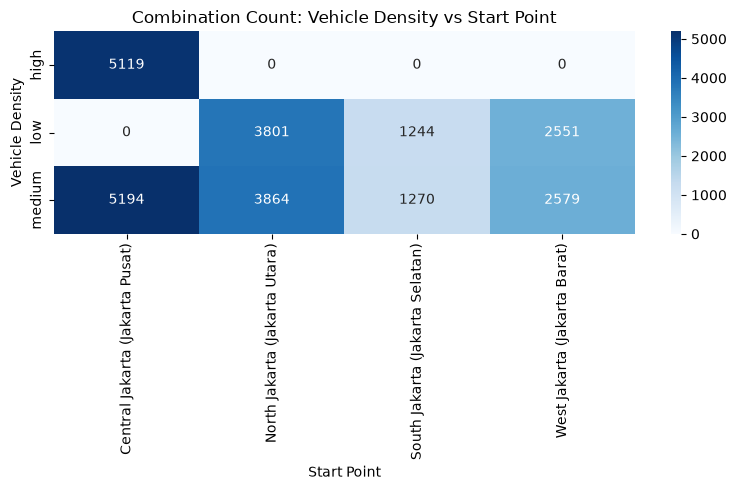

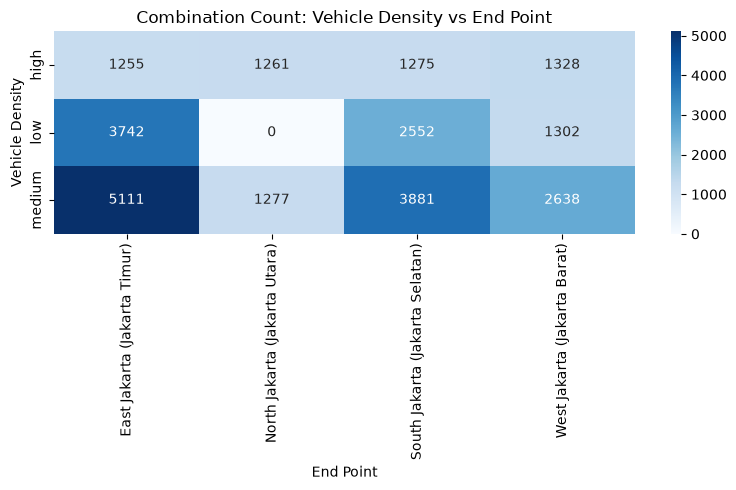

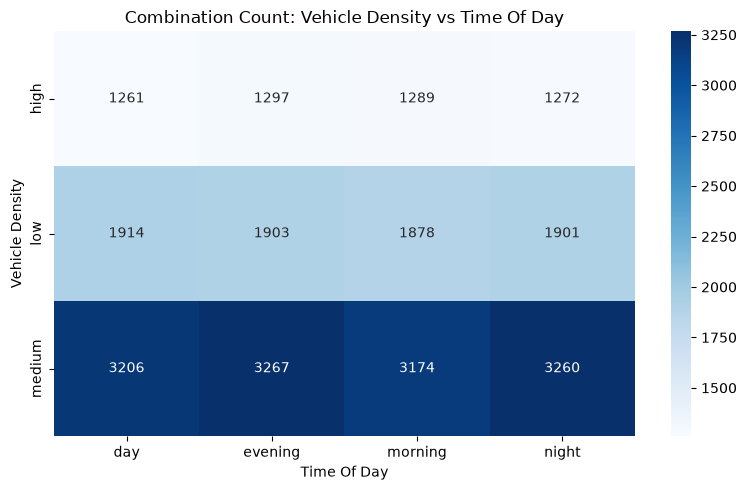

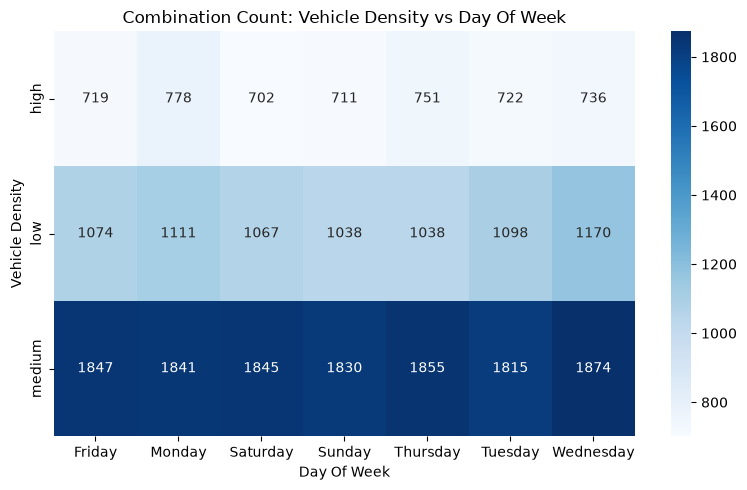

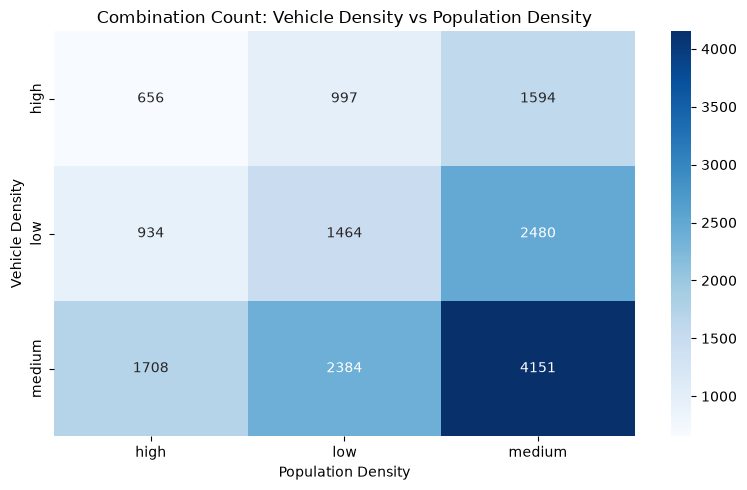

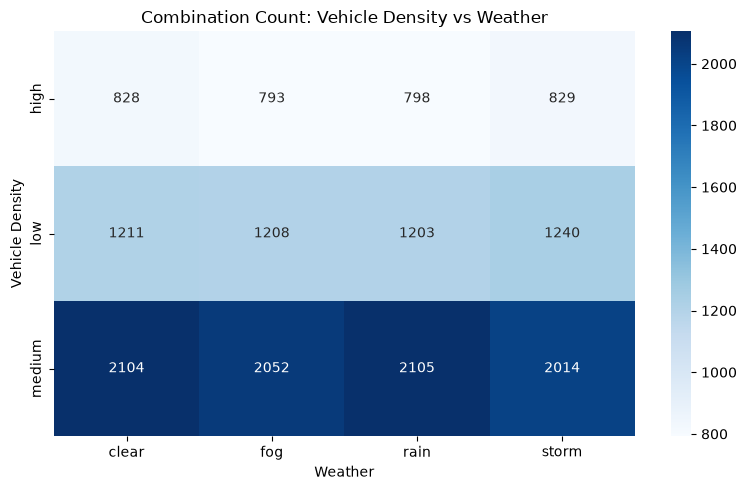

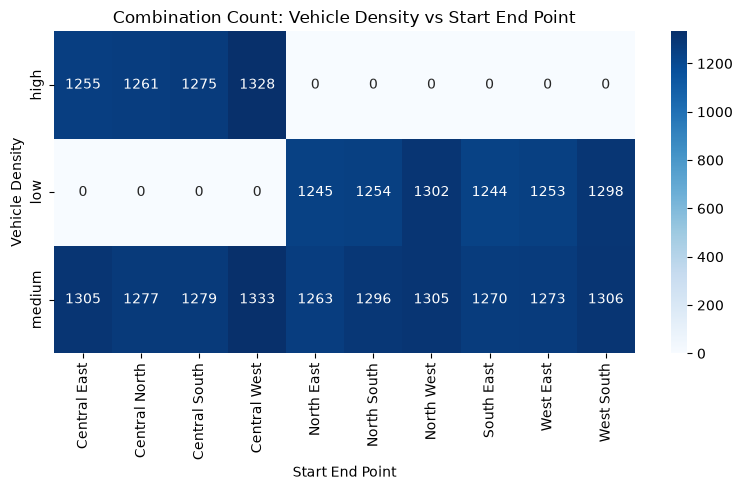

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil semua kolom kategorikal
categorical_cols = train_sample.select_dtypes(
    include=["object", "str"]
).columns

# Loop setiap kolom kategorikal
for col in categorical_cols:

    if col == "vehicle_density":
        continue

    # Hitung kombinasi
    counts = pd.crosstab(
        train_sample["vehicle_density"],
        train_sample[col]
    )

    # Buat heatmap
    plt.figure(figsize=(8, 5))

    sns.heatmap(
        counts,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Vehicle Density")
    plt.title(
        f"Combination Count: Vehicle Density vs {col.replace('_', ' ').title()}"
    )

    plt.tight_layout()
    plt.show()

if start_point == 'Central' then vehicle_density = 'high'


else vehicle_density = 'medium'

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

features = [
    "start_point",
    "end_point",
    "time_of_day",
    "day_of_week",
    "traffic_condition",
    "event_count",
    "is_holiday",
    "weather",
    "population_density",
    "public_transport_availability",
    "historical_delay_factor",
    "start_end_point"
]

target = "vehicle_density"

In [32]:
known_data = train_sample[
    train_sample[target].notna() & train_sample[features].notna().all(axis=1)
].copy()

X = known_data[features]
y = known_data[target]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
categorical_features = [
    "start_point",
    "end_point",
    "time_of_day",
    "day_of_week",
    "weather",
    "population_density",
    "public_transport_availability",
    "start_end_point"
]

numeric_features = [
    "traffic_condition",
    "event_count",
    "is_holiday",
    "historical_delay_factor"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ],
    remainder="passthrough"
)

In [35]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ))
])

In [36]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['high','low','medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['start_point','end_point','time_of_day',..., 'public_transport_availability','historical_delay_factor', 'start_end_point']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are drop

In [37]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.46      0.53      0.49       269
         low       0.53      0.31      0.39       400
      medium       0.50      0.59      0.54       675

    accuracy                           0.49      1344
   macro avg       0.50      0.48      0.47      1344
weighted avg       0.50      0.49      0.49      1344



In [38]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[142   0 127]
 [  0 123 277]
 [168 108 399]]


In [39]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    ))
])

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        high       0.47      1.00      0.64       269
         low       0.52      0.98      0.68       400
      medium       0.60      0.02      0.03       675

    accuracy                           0.50      1344
   macro avg       0.53      0.67      0.45      1344
weighted avg       0.55      0.50      0.35      1344



In [40]:
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ))
])

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        high       0.46      0.49      0.48       269
         low       0.54      0.45      0.49       400
      medium       0.51      0.55      0.53       675

    accuracy                           0.51      1344
   macro avg       0.50      0.49      0.50      1344
weighted avg       0.51      0.51      0.50      1344



In [1]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
model_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [ ]:
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

In [27]:
pd.crosstab(
    train_sample["traffic_condition"],
    train_sample["vehicle_density"],
    normalize="index"
) * 100

vehicle_density,high,low,medium
traffic_condition,,,
3.0,18.750000,29.687500,51.562500
5.0,19.760663,28.965940,51.273397
7.0,24.022346,24.022346,51.955307
8.0,31.896552,27.586207,40.517241
9.0,19.982283,29.473551,50.544166
10.0,19.643966,30.511281,49.844753


# **traffic_condition**

In [15]:
df_traffic_condition_null = train_sample[train_sample['traffic_condition'].isnull()]

In [16]:
df_traffic_condition_null.head(20)

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time,start_end_point
0,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),day,Sunday,NaN,9,1,NaN,high,NaN,1,0.878909,26.907612,West South
1,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Thursday,NaN,7,1,medium,high,NaN,1,1.081668,27.489129,West South
2,Central Jakarta (Jakarta Pusat),East Jakarta (Jakarta Timur),morning,Thursday,NaN,7,0,medium,low,NaN,2,1.192379,27.228978,Central East
4,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),day,Tuesday,NaN,7,0,medium,high,rain,2,0.966819,20.603115,Central West
6,Central Jakarta (Jakarta Pusat),East Jakarta (Jakarta Timur),morning,Tuesday,NaN,8,1,medium,medium,NaN,2,0.951060,21.221348,Central East
7,West Jakarta (Jakarta Barat),East Jakarta (Jakarta Timur),day,Saturday,NaN,9,0,medium,low,rain,2,1.141605,38.019252,West East
9,South Jakarta (Jakarta Selatan),East Jakarta (Jakarta Timur),day,Tuesday,NaN,7,1,medium,medium,rain,2,0.967703,18.766079,South East
10,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),evening,Sunday,NaN,9,1,NaN,low,NaN,2,1.098704,25.727184,Central West
11,West Jakarta (Jakarta Barat),East Jakarta (Jakarta Timur),morning,Friday,NaN,7,0,low,NaN,fog,2,0.957430,48.266505,West East
13,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),day,Sunday,NaN,8,1,medium,low,NaN,2,0.925556,61.747568,North East


In [20]:
df_traffic_condition_null.start_end_point.value_counts()

start_end_point
Central West     1529
South East       1463
West South       1451
North East       1446
North West       1445
Central North    1440
West East        1439
Central East     1428
North South      1395
Central South    1365
Name: count, dtype: int64

In [18]:
df_traffic_condition_null.describe()

,traffic_condition,event_count,is_holiday,public_transport_availability,historical_delay_factor,travel_time
count,0.0,14401.000000,14401.000000,14401.000000,14401.000000,14401.000000
mean,NaN,8.688286,0.500868,1.506909,1.008227,30.531767
std,NaN,5.336495,0.500017,0.671315,0.162328,15.127267
min,NaN,7.000000,0.000000,0.000000,0.750009,2.490207
25%,NaN,7.000000,0.000000,1.000000,0.877609,18.726979
50%,NaN,8.000000,1.000000,2.000000,1.000751,26.790501
75%,NaN,9.000000,1.000000,2.000000,1.130205,39.943612
max,NaN,87.000000,1.000000,2.000000,1.872459,205.679832


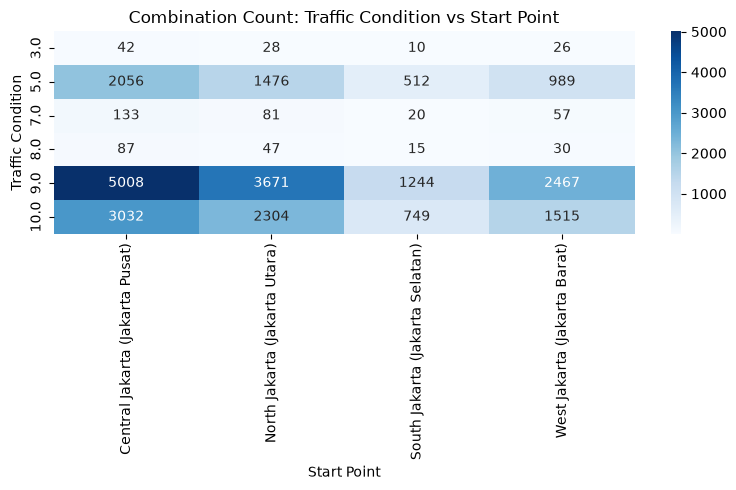

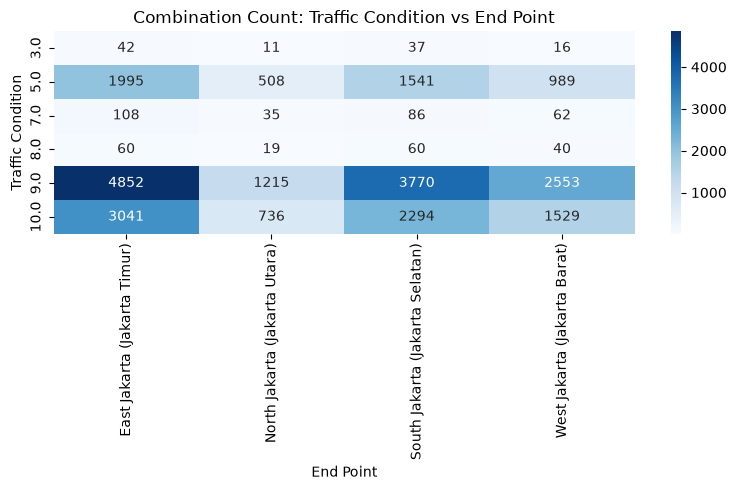

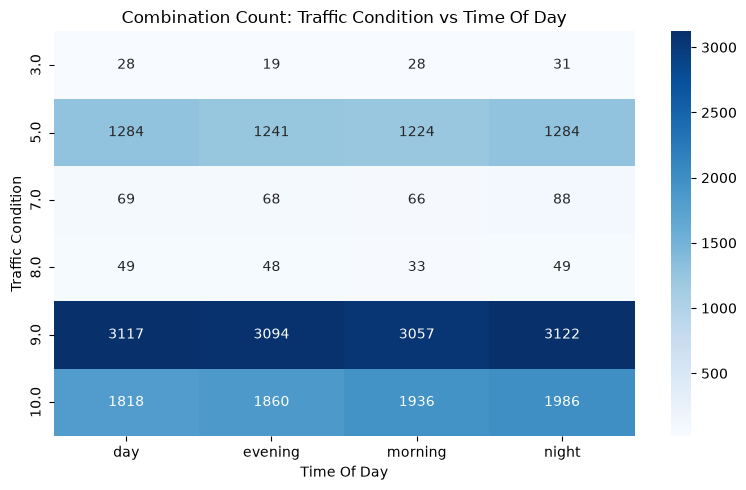

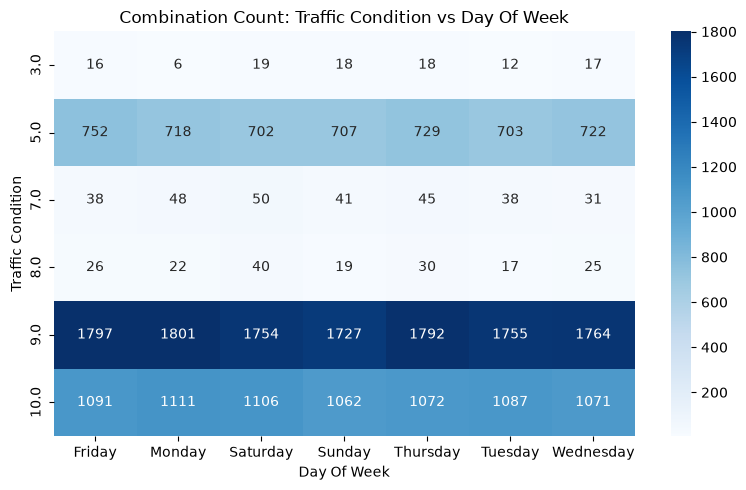

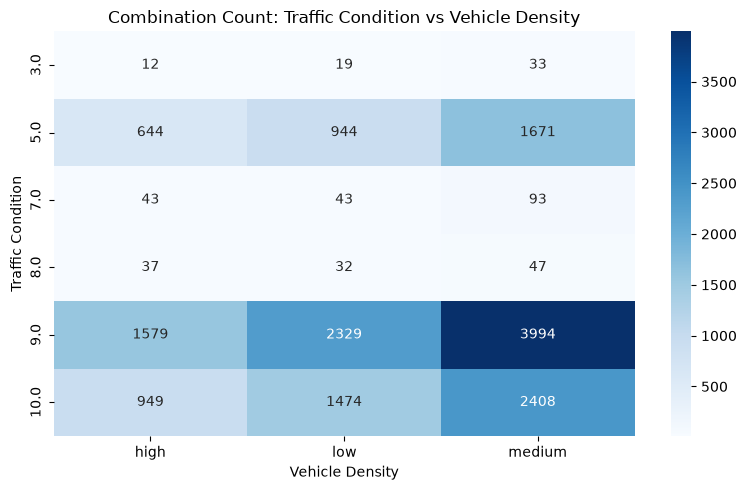

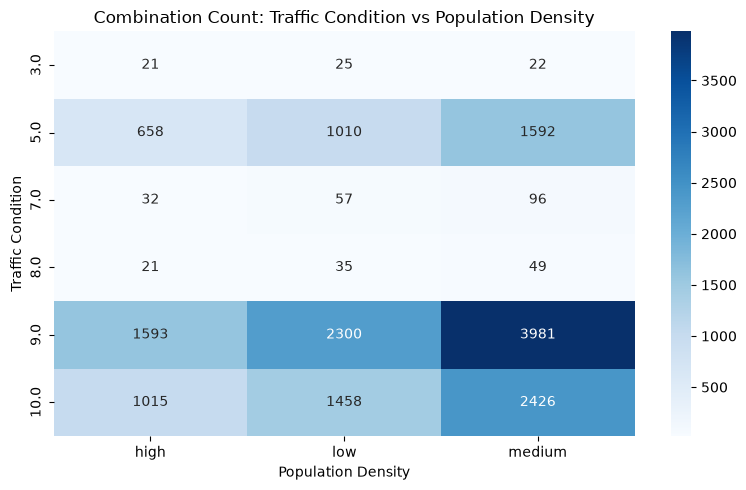

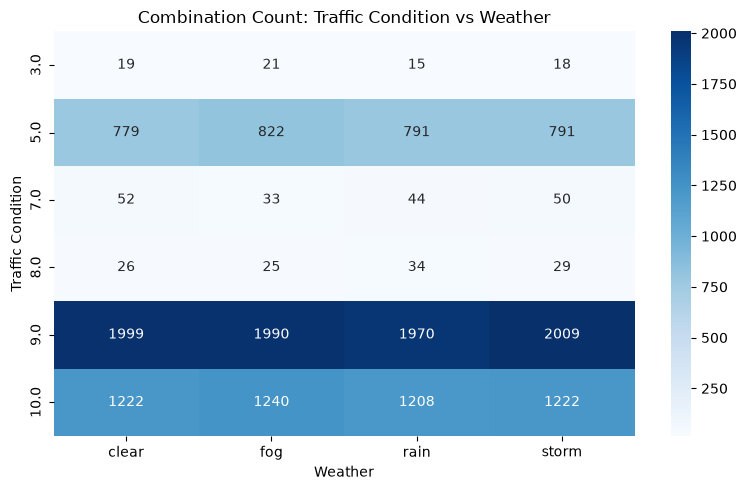

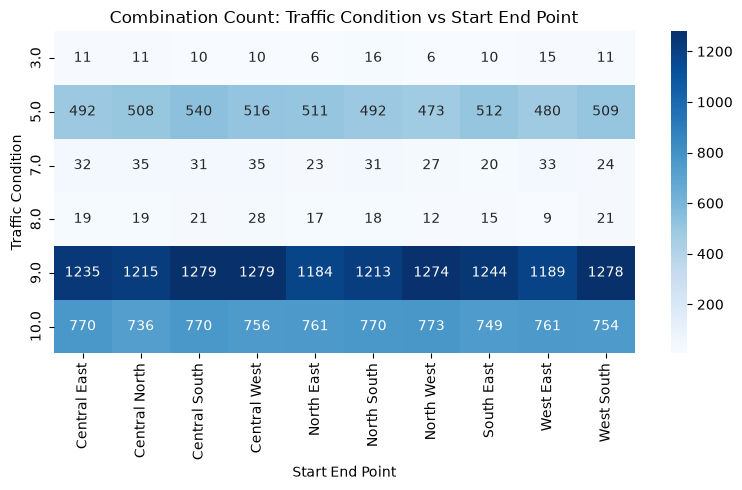

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil semua kolom kategorikal
categorical_cols = train_sample.select_dtypes(
    include=["object", "str"]
).columns

# Loop setiap kolom kategorikal
for col in categorical_cols:

    # Skip traffic_condition
    if col == "traffic_condition":
        continue

    # Hitung kombinasi
    counts = pd.crosstab(
        train_sample["traffic_condition"],
        train_sample[col]
    )

    # Buat heatmap
    plt.figure(figsize=(8, 5))

    sns.heatmap(
        counts,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Traffic Condition")
    plt.title(
        f"Combination Count: Traffic Condition vs {col.replace('_', ' ').title()}"
    )

    plt.tight_layout()
    plt.show()

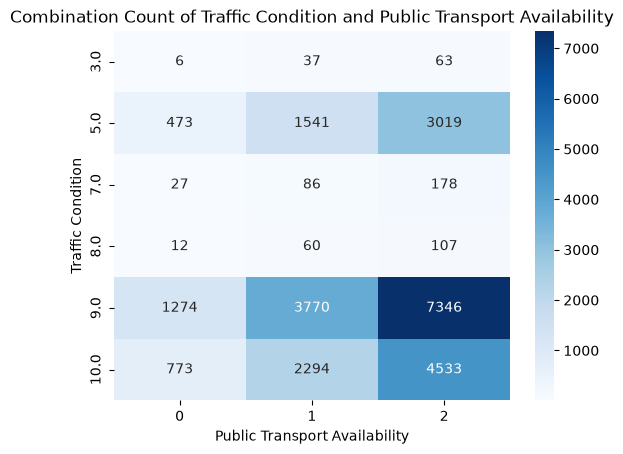

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# hitung kombinasi
counts = pd.crosstab(train_sample["traffic_condition"], train_sample["public_transport_availability"])

# plot
sns.heatmap(
    counts,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Public Transport Availability")
plt.ylabel("Traffic Condition")
plt.title("Combination Count of Traffic Condition and Public Transport Availability")
plt.show()